# ResNet50 Training

## Imports

✅ Dataloaders loaded successfully
Train batches: 92 | Val batches: 23


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/myid/rm98243/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s] 


⚡ Using 2 GPUs!


Epoch 1/15 [Val]: 100%|██████████| 23/23 [00:40<00:00,  1.78s/it]


...


Epoch [13/15] → Train Loss: 0.2492 | Val Loss: 1.1277 | Val Acc: 0.6999


Epoch 14/15 [Val]: 100%|██████████| 23/23 [00:40<00:00,  1.78s/it]



Epoch [14/15] → Train Loss: 0.2282 | Val Loss: 1.1292 | Val Acc: 0.7176


Epoch 15/15 [Val]: 100%|██████████| 23/23 [00:40<00:00,  1.77s/it]



Epoch [15/15] → Train Loss: 0.2245 | Val Loss: 1.1414 | Val Acc: 0.7271

✅ Training Complete. Best Validation Accuracy: 0.7271


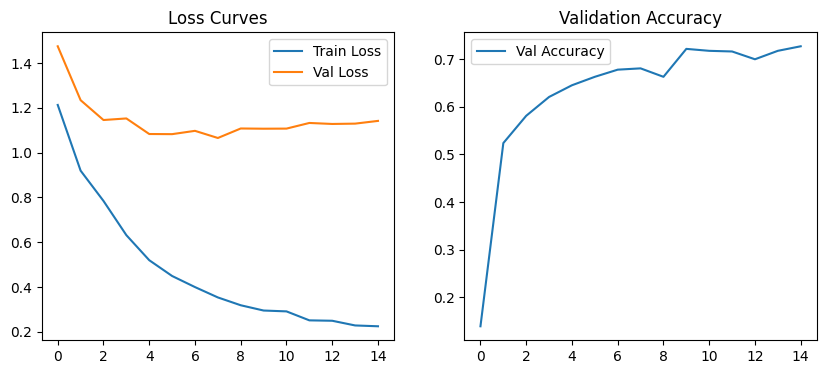


Classification Report:

              precision    recall  f1-score   support

           0     0.9454    0.9584    0.9519       361
           1     0.3909    0.5811    0.4674        74
           2     0.7519    0.4850    0.5897       200
           3     0.2537    0.4359    0.3208        39
           4     0.4918    0.5085    0.5000        59

    accuracy                         0.7271       733
   macro avg     0.5667    0.5938    0.5659       733
weighted avg     0.7633    0.7271    0.7342       733



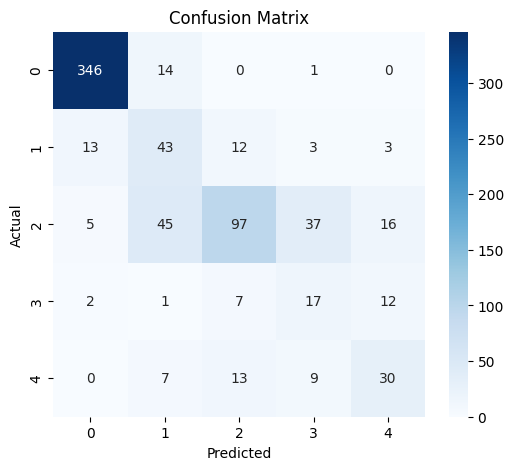

In [ ]:
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

def apply_clahe(img, **kwargs):
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) for retinal enhancement."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return enhanced_img


def circular_crop(img, **kwargs):
    """Apply circular crop to focus on the retina region."""
    height, width, _ = img.shape
    center = (int(width/2), int(height/2))
    radius = min(center[0], center[1], width - center[0], height - center[1])

    Y, X = np.ogrid[:height, :width]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    mask = dist_from_center <= radius
    cropped = np.zeros_like(img)
    cropped[mask] = img[mask]

    cropped = cv2.resize(cropped, (224, 224))
    return cropped


## Custom Dataset Class (for pickle loading)

In [ ]:
from PIL import Image

class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.loc[idx, 'id_code']
        label = int(self.dataframe.loc[idx, 'diagnosis'])
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        image = np.array(Image.open(img_path).convert('RGB'))

        if self.transform:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)

## Load Dataloaders from Pickle

In [ ]:
with open("../data/processed/loaders.pkl", "rb") as f:
    data_objects = pickle.load(f)

train_loader = data_objects["train_loader"]
val_loader   = data_objects["val_loader"]
class_weights = data_objects["class_weights"]

print("Dataloaders loaded successfully")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Test sample batch
for imgs, labels in train_loader:
    print(f"Image batch shape: {imgs.shape}")
    print(f"Label batch shape: {labels.shape}")
    break

# 3Device & GPU Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.backends.cudnn.benchmark = True




## Model Setup (ResNet50)

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in model.parameters():
    param.requires_grad = True  # fine-tune all layers

# Modify final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)
model = model.to(device)

# Multi-GPU if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)


# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

## Training Function

In [ ]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs=15):
    best_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history["train_loss"].append(epoch_loss)

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step()

        print(f"\nEpoch [{epoch+1}/{epochs}] → Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "../models/best_resnet50.pth")

    print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.4f}")
    return history



# Train Model
history = train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs=15)

## Plot Training Curves

In [ ]:

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(history["val_acc"], label="Val Accuracy")
plt.legend(); plt.title("Validation Accuracy")
plt.show()


# Evaluate on Validation Set
model.load_state_dict(torch.load("../models/best_resnet50.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()